[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/notebooks/01_Descriptive_Research/HMMTVTP_InSample_Regime_Analysis_EquityBond.ipynb)


# Correlation between equity and bond indices: regime description of market states between the S&P 500 and the 10-year Treasury Bond from 1970 to 2025, and the relationship between their changes and macroeconomic variables.

This code is purely descriptive (fully in-sample). It initializes an HMM TVTP and fits it to the log returns of the S&P 500 and the 10-year U.S. Treasury Bond over the period 1970 to 2025, identifying four distinct market regimes whose transitions are influenced by macroeconomic variables.

To interpret the economic meaning of each regime, a `RegimeStatisticalAnalyzer` object is used to compute and display regime-conditional means, volatilities, and cross-asset correlations. In addition, statistical tests across regimes are performed (Levene’s test for volatility differences and Fisher’s z-transformation for correlation differences).

For the transition parameters, their uncertainty is obtained by approximating the Fisher information matrix via the numerical Hessian of the log-likelihood.


# Connection to GitHub

In [ ]:
import os
import sys

# 1. Environment check
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone the repository
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Move to the project directory
    os.chdir(repo_name)

    # 4. Add the project path to the system path for importing .py modules
    sys.path.append(os.getcwd())

    print(f"Current working directory: {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 971, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 971 (delta 148), reused 73 (delta 73), pack-reused 751 (from 2)
Receiving objects: 100% (971/971), 21.33 MiB | 18.34 MiB/s, done.
Resolving deltas: 100% (463/463), done.
Current working directory: /content/CorrelationEquityBond


# Installation of the ssm library via the Git repository

In [ ]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-nrt_y8va
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-nrt_y8va
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done
  Created wheel for ssm: filename=ssm-0.0.1-cp312-cp312-linux_x86_64.whl size=614352 sha256=43afd6acea6734a3c351947e30a136a58c2c6f26cedb49ccc0c90cfdcb130520
  Stored in directory: /tmp/pip-ephem-wheel-cache-utg42xyc/wheels/a8/a9/68/b62b9b4d4ee3afda66bd9eec0cb2fbc9a79a7504e9d6d17397
Successfully built ssm


# Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from src.stock_bond_correlation.models.HMMMarketWithMacroTransitionsRegimeDetector import HMMMarketWithMacroTransitionsRegimeDetector
from src.stock_bond_correlation.diagnostics.statistical_tests.HMMCoherenceChecker import HMMCoherenceChecker
from src.stock_bond_correlation.visualization.RegimeReporter import RegimeReporter

# Data preparation

In [ ]:
df = pd.read_csv("data/dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

In [ ]:
df.head()

,Price,Dividend,Earnings,CPI,Rate GS10,Real Price,Real Dividend,Real Total Return,Real Earnings,Real TR Scaled Earnings,...,PAYEMS,CUMFNS,TCU,UNRATE,DGS10,M2SL,USRECD,PPIACO,AAA_Log_Return,BAA_Log_Return
Date,,,,,,,,,,,,,,,,,,,,,
1934-01-01,10.54,0.44,0.44,13.2,3.12,258.15,10.80,7283.51,10.88,306.96,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.4,NaN,NaN
1934-02-01,11.32,0.44,0.45,13.3,3.09,275.17,10.74,7788.94,10.90,308.46,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.035091,-0.111561
1934-03-01,10.74,0.44,0.45,13.3,3.07,261.07,10.76,7415.24,11.00,312.42,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.016807,-0.001596
1934-04-01,10.92,0.44,0.46,13.3,3.04,265.45,10.78,7565.02,11.10,316.39,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.014634,-0.040755
1934-05-01,9.81,0.44,0.46,13.3,3.01,238.47,10.80,6821.69,11.20,320.43,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.7,-0.014852,0.006634


In [ ]:
ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
MACRO_VARS = ["inflation_yoy", "credit_spread_diff", "slope_neg"]
asset_names = ["S&P", "T-bond 10y"]

# Macro feature engineering
df['inflation_yoy'] = df['CPI'].pct_change(12)
df['credit_spread'] = (df['BAA'] - df['AAA'])
df['credit_spread_diff'] = df['credit_spread'].diff()
df['slope_neg'] = (df['Rate GS10'] - df['TB3MS']) <= 0

# Ensuring causality by lagging macro variables
df[MACRO_VARS] = df[MACRO_VARS].shift(1)

cols_to_keep = ASSET_VARS + MACRO_VARS
df_model = df[cols_to_keep].dropna().copy()

# Time filtering
dates = df_model.index
train_mask = (dates >= pd.Timestamp("1970-01-01")) & (dates <= pd.Timestamp("2025-01-01"))  # full descriptive sample from 1970

dates_train = dates[train_mask]
Y_train = df_model.loc[train_mask, ASSET_VARS].to_numpy(dtype=float)
X_train = df_model.loc[train_mask, MACRO_VARS].to_numpy(dtype=float)

# Standardization of covariates
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

data_to_fit = [np.ascontiguousarray(Y_train * 100)]
input_to_fit = [np.ascontiguousarray(X_train_scaled)]

T, D = data_to_fit[0].shape
M = X_train_scaled.shape[1]

# Initialization and fitting of the descriptive HMM TVTP

In [ ]:
# HMM TVTP model
detector_hmm_tvtp = HMMMarketWithMacroTransitionsRegimeDetector(
    n_regimes=4,
    n_dim=len(ASSET_VARS),
    n_input=len(MACRO_VARS),
    random_state=42,
    transition_kwargs={"alpha": 1, "kappa": 10, "l2_penalty": 1.5}
)

detector_hmm_tvtp.fit(
    observations=data_to_fit,
    inputs=input_to_fit,
    feature_names=MACRO_VARS,
    asset_names=asset_names
)

states = detector_hmm_tvtp.viterbi_states

# Model coherence / stability assessment
checker = HMMCoherenceChecker(
    detector=detector_hmm_tvtp,
    log_returns=data_to_fit[0],
    covariate_names=MACRO_VARS,
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.05
)

checker.report_emission_stats()  # emission parameters

for ref_idx in range(4):
    checker.report_transition_stats(
        inputs=input_to_fit[0],
        ref_idx=ref_idx
    )  # transition parameters

checker.final_verdict(inputs=input_to_fit[0])  # automated final assessment

Initialization: Fitting stationary HMM...

STATIONARY HMM INITIALIZATION AUDIT (EMISSION)
 Regime      Asset   N      Mean      Vol   Ann_Vol
      0        S&P  89 -2.157224 6.066754 21.015853
      0 T-bond 10y  89  1.024538 1.823782  6.317767
      1        S&P 360  1.443084 2.725281  9.440651
      1 T-bond 10y 360  0.648077 1.799775  6.234602
      2        S&P  61  0.230578 4.832204 16.739247
      2 T-bond 10y  61  0.178050 3.926812 13.602877
      3        S&P 151  1.514595 1.958588  6.784748
      3 T-bond 10y 151  0.072864 1.346776  4.665368

LOGISTIC REGRESSION INITIALIZATION AUDIT (TRANSITION)

=== INITIAL LOGISTIC REGRESSION WEIGHTS (X_{t-1} -> Z_t) ===
                      Intercept  inflation_yoy  credit_spread_diff  slope_neg
Regime 0 Probability    -0.1438        -0.0189              0.4047     0.1763
Regime 1 Probability     1.3441         0.1489             -0.1998    -0.0305
Regime 2 Probability    -1.1241         1.2738             -0.1112    -0.0636
Regime 3 Prob

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



COMPLETE EMISSIONS DIAGNOSTIC (BOOTSTRAP & TESTS)

1. ANNUAL VOLATILITIES WITH CONFIDENCE INTERVALS:


Value  Lower_Bound  Upper_Bound
Regime Label                                        
0      S&P         21.0889      17.2190      24.8008
       T-bond 10y   6.3825       5.3883       7.3282
1      S&P          9.4255       8.6851      10.1691
       T-bond 10y   6.1368       5.6405       6.6040
2      S&P         16.1645      12.8194      19.0247
       T-bond 10y  14.0548      11.2036      16.4658
3      S&P          6.8443       5.9834       7.6215
       T-bond 10y   4.7651       4.1537       5.3221


2. CORRELATIONS WITH CONFIDENCE INTERVALS:


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,3.0011,0.7294,0.0000,True
1,Intercept,R0 -> R1,Base_Prob,-0.2322,0.9902,0.8146,False
2,Intercept,R0 -> R2,Base_Prob,-2.7100,2.2113,0.2204,False
3,Intercept,R1 -> R0,Base_Prob,0.8573,1.4966,0.5668,False
4,Intercept,R1 -> R1,Base_Prob,5.7422,1.1598,0.0000,True
5,Intercept,R1 -> R2,Base_Prob,-0.8944,2.1749,0.6809,False
6,Intercept,R2 -> R0,Base_Prob,4.4089,4.6949,0.3477,False
7,Intercept,R2 -> R1,Base_Prob,5.4873,4.5341,0.2262,False
8,Intercept,R2 -> R2,Base_Prob,8.0529,4.5197,0.0748,False
9,Intercept,R3 -> R0,Base_Prob,-2.3692,0.5670,0.0000,True



2. AVERAGE DYNAMICS AND PERSISTENCE:


,Average_Duration (months),Stationary_Prob,Stay_Prob
0,8.2707,0.1919,0.8791
1,31.0233,0.5760,0.9678
2,7.4766,0.0976,0.8662
3,6.4715,0.1345,0.8455



HMM COHERENCE REPORT : 82.84%
1. SEPARABILITY : 72.2% (Threshold: 50%) -> OK
2. STABILITY    : VALID
3. PERSISTENCE  : 6.5 months (min 3.0) -> OK
4. CONFIDENCE   : 87.2% (Entropy) -> SOLID
--------------------------------------------------
REGIME DYNAMICS:
   Duration   Freq
0     8.271  0.192
1    31.023  0.576
2     7.477  0.098
3     6.471  0.135

VERDICT: MODEL VALIDATED (Robust)


np.float64(0.8284323396458955)

We obtain results that are broadly consistent with those of the HMM Market model, which suggests a degree of stability.

Moreover, the model is able to establish coherent and statistically meaningful relationships between macroeconomic variables and market regime shifts (e.g., a significant role of inflation in transitions toward Regime 3 — inflationary stress — or a significant role of credit spreads in transitions toward Regime 1 — flight-to-quality).

We therefore appear to identify four distinct market regimes:

1. Flight-to-quality (negative correlation, high volatility, typical of 2008 or 2020)
2. Normal regime (positive correlation, low volatility)
3. Inflationary stress regime (positive correlation, high volatility, typical of the 1970s or 2022)
4. Ideal diversification regime (negative correlation, low volatility, pre-2010 period)

Regarding the statistical tests, the results from Levene’s test and the Fisher z-transformation are conclusive (at least one of the two is significant for each pairwise comparison).

For the transition parameters, the intercepts of self-transitions (from a regime to itself) are significant across all reference indices.

It is also noteworthy that no negative eigenvalues are observed in the Fisher information matrix, and entropy is confirmed.

# Graphical visualization

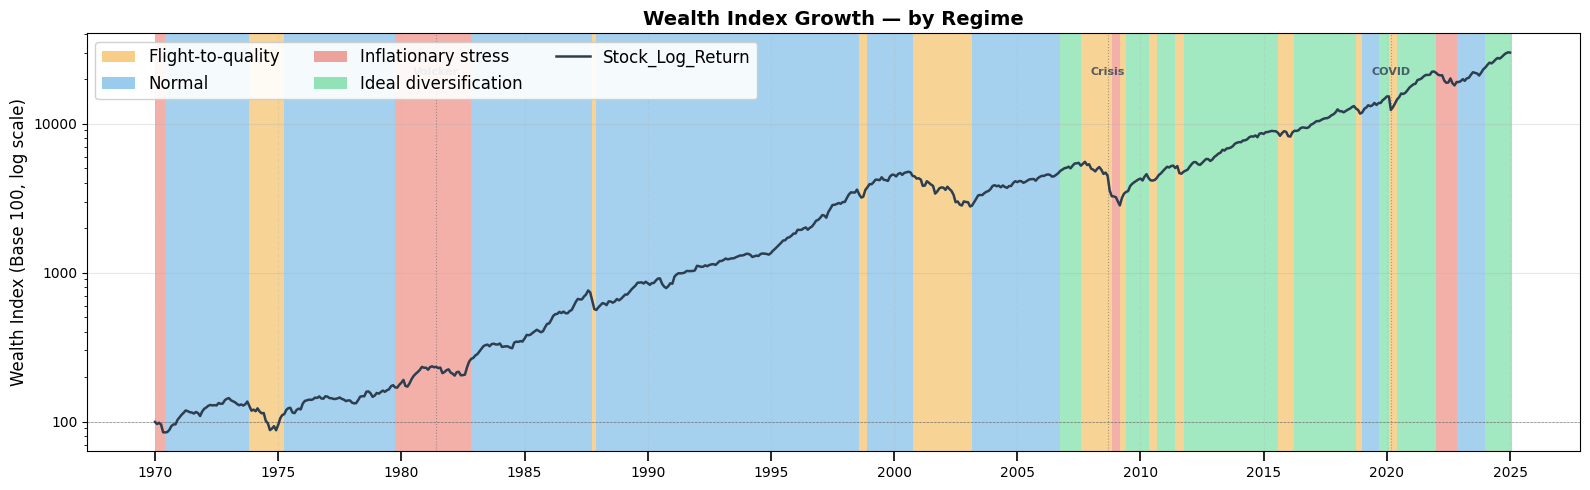

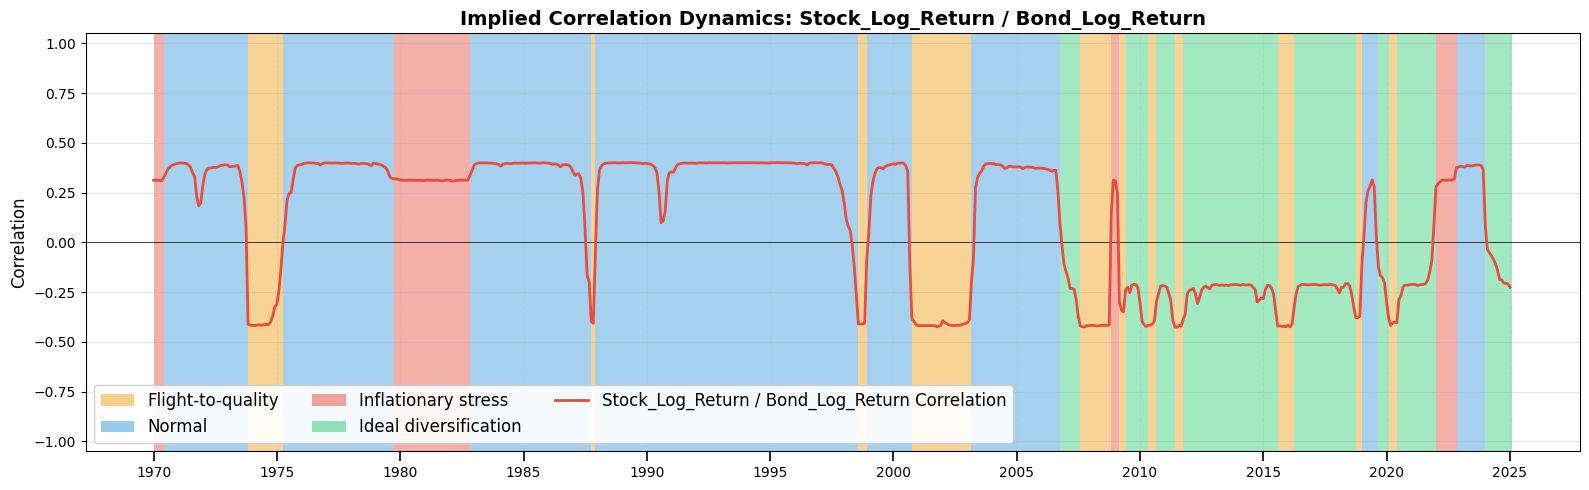

In [ ]:
regime_labels = {
    0: "Flight-to-quality",
    1: "Normal",
    2: "Inflationary stress",
    3: "Ideal diversification"
}  # the four identified regimes

regime_colors = {
    0: "#f39c12",
    1: "#3498db",
    2: "#e74c3c",
    3: "#2ecc71"
}  # color choices

crisis_events = {
    "Volcker": "1981-06-01",
    "Crisis": "2008-09-01",
    "COVID": "2020-03-01"
}  # key dates for easier identification

# Generic instantiation
visualizer = RegimeReporter(
    detector=detector_hmm_tvtp,
    log_returns=data_to_fit[0] / 100,  # removing the previous multiplication by 100
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=regime_labels,
    regime_colors=regime_colors,
    events_dict=crisis_events
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()